In [ ]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import PosteriorManifold, FisherPosteriorManifold, FisherLogPosteriorManifold
from utils import categorical_entropy, get_random_image, get_random_images
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import torch.distributions as D

transform = v2.Compose([
    v2.Resize((64, 64), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
trainset = torchvision.datasets.MNIST(root='datasets', transform=transform, download=True, train=True)
testset = torchvision.datasets.MNIST(root='datasets', transform=transform, download=True, train=False)
dataset = torch.utils.data.ConcatDataset((trainset, testset))
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

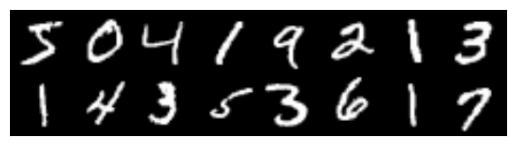

In [3]:
imgs, labels = next(dataloader.__iter__())
seven = imgs[0]
show_img(make_grid(imgs))

/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae/model.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(fname

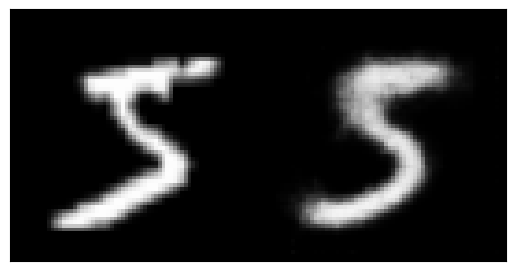

In [4]:
from pretrained_models import MNIST_VAE
vae = MNIST_VAE(n_latent=8)
with torch.no_grad():
    reconstructed = vae.reconstruct(seven)
    show_img(make_grid(torch.stack((seven, reconstructed))))

In [53]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title: ax.set_title(title)

In [6]:
gmm = ConditionalGMM(n_dim=8, n_classes=10)
with torch.no_grad():
    for images, class_labels in dataloader:
        gmm.update(vae.encode(images.cuda()), class_labels.cuda())
    gmm.fit()

### Drawing samples from the GMM

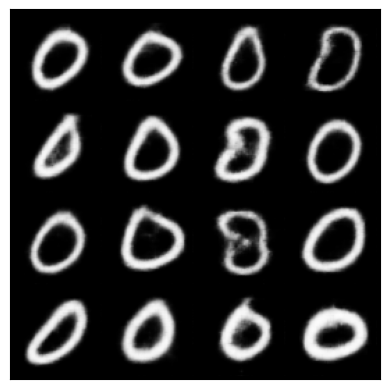

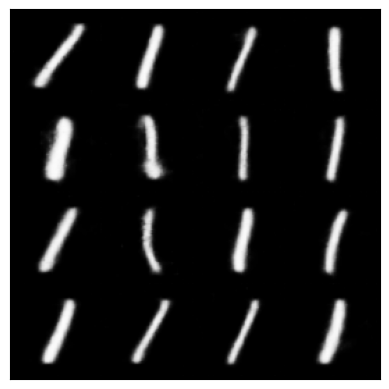

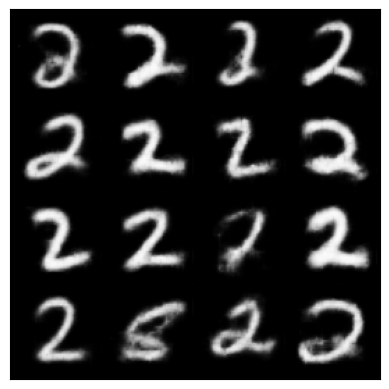

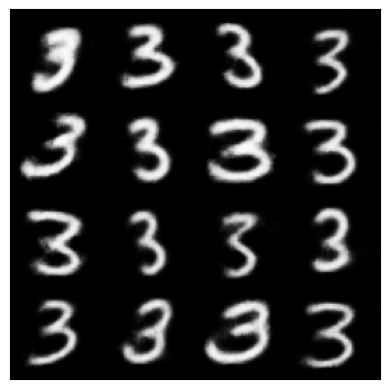

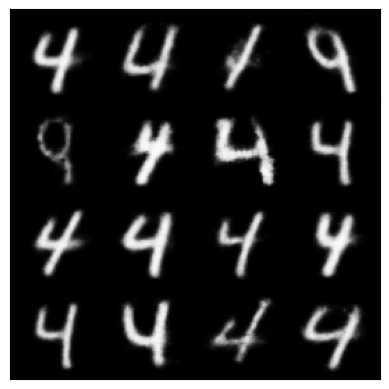

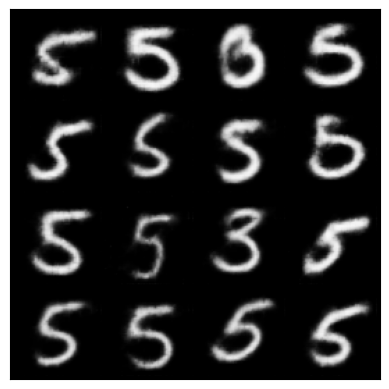

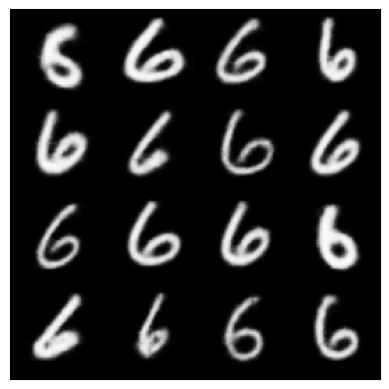

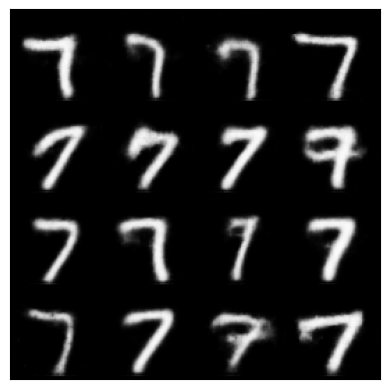

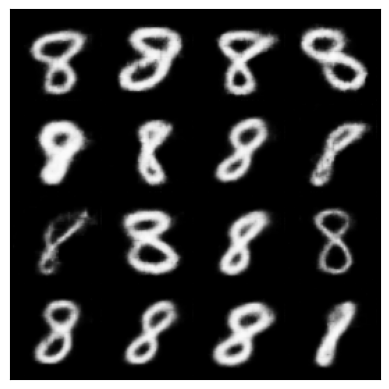

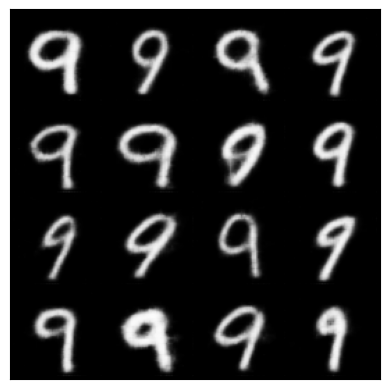

In [ ]:
samples = gmm.gmm.component_distribution.sample((16,)).swapaxes(0, 1)
for i in range(10):
    show_img(make_grid(vae.decode(samples[i]), nrow=4))

### Drawing samples from a GMM (whole dataset)

In [190]:
samples = gmm.gmm.component_distribution.sample((16,)).swapaxes(0, 1)

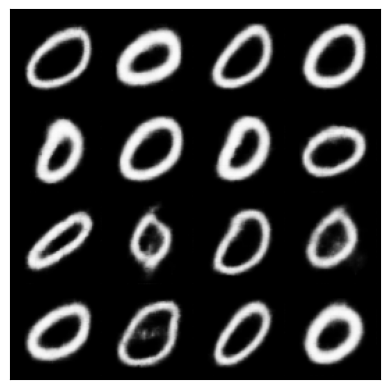

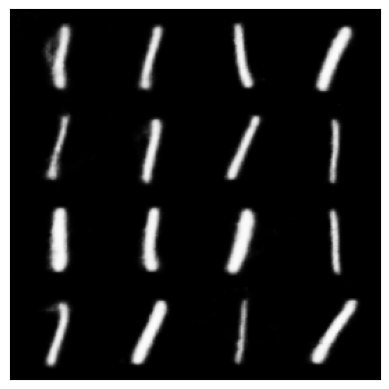

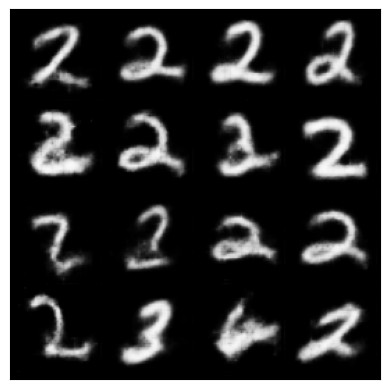

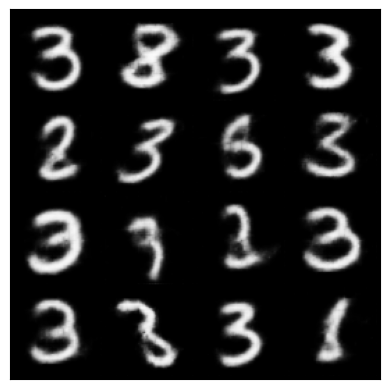

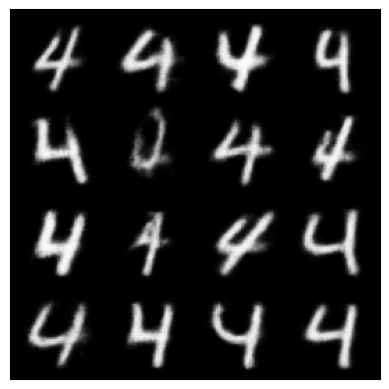

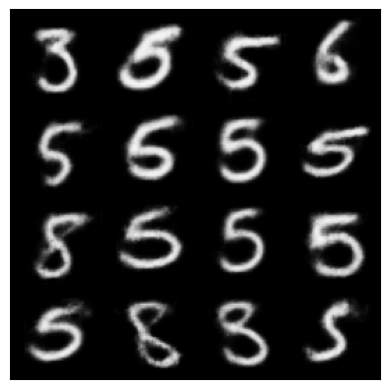

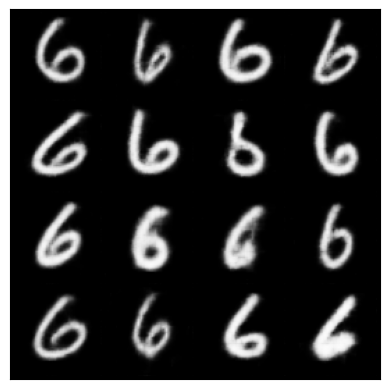

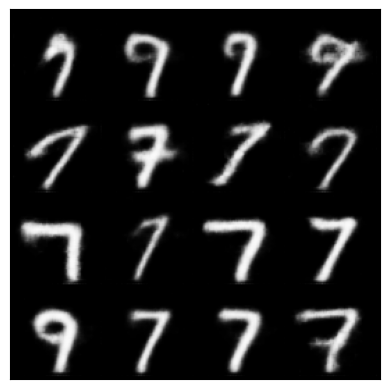

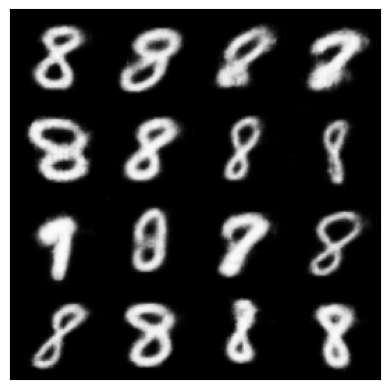

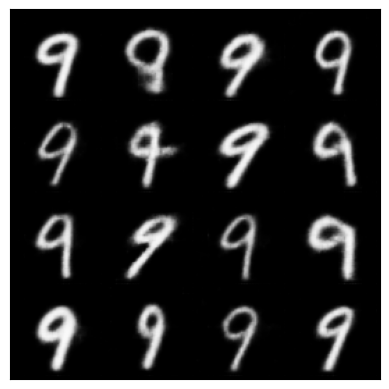

In [191]:
for i in range(10):
    show_img(make_grid(vae.decode(samples[i]), nrow=4))

### Proceeding with the posterior manifold

In [8]:
M = FisherLogPosteriorManifold(gmm.log_posterior)

In [236]:
def compute_geodesic_and_compare_to_lerp(im1, im2, manifold = M, n_iter=10000):
    geodesic = manifold.optimize_geodesic(vae.encode(im1), vae.encode(im2), lr=0.001, n_subdiv=7, n_iter=n_iter)
    linline = lerp(vae.encode(im1), vae.encode(im2), n=16)
    _, (axl, axr) = plt.subplots(1, 2, figsize=(12, 6))
    show_img(make_grid(vae.decode(geodesic), nrow=4), ax=axl)
    axl.set_title('Geodesic')
    show_img(make_grid(vae.decode(linline), nrow=4), ax=axr)
    axr.set_title('Linear Interpolation')

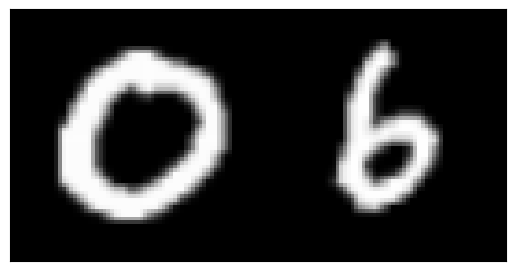

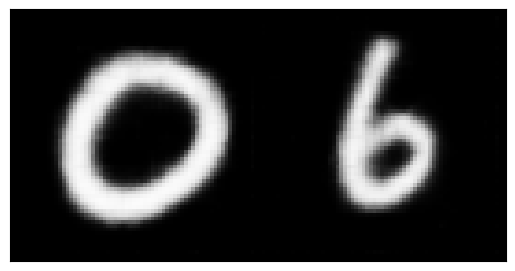

In [9]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

In [31]:
linline = lerp(*vae.encode(random_imgs), n=16)

optimizing geodesic: 100%|██████████| 30000/30000 [01:52<00:00, 266.66it/s, loss=0.0943]


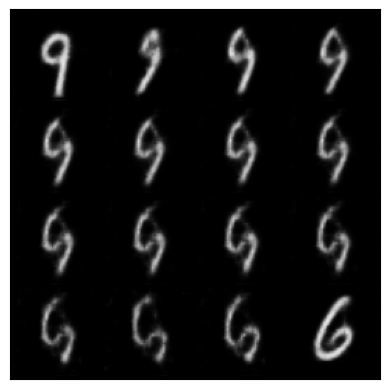

In [30]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), lr=0.01, n_subdiv=7, n_iter=30000) #type:ignore
show_img(make_grid(vae.decode(geodesic), nrow=4))

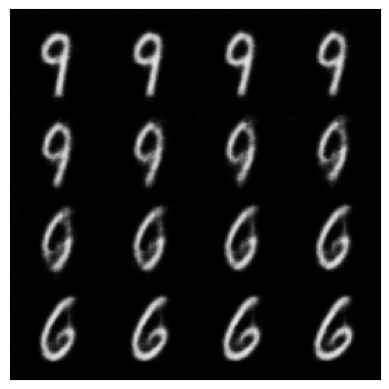

In [26]:
linline = lerp(*vae.encode(random_imgs), n=16)
show_img(make_grid(vae.decode(linline), nrow=4))

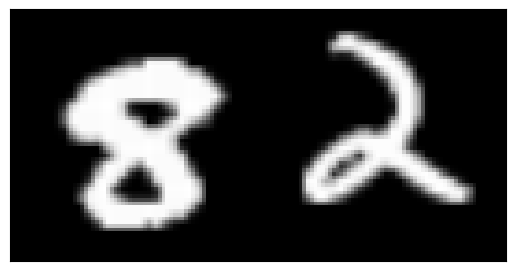

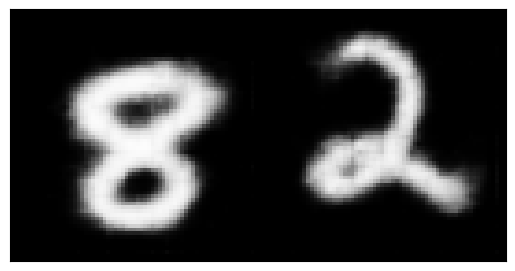

In [35]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 30000/30000 [01:53<00:00, 265.00it/s, loss=0.0877]


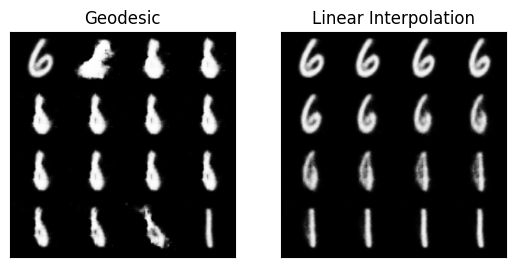

In [33]:
compute_geodesic_and_compare_to_lerp(*random_imgs)

optimizing geodesic:   0%|          | 0/30000 [00:00<?, ?it/s]

optimizing geodesic: 100%|██████████| 30000/30000 [02:09<00:00, 231.67it/s, loss=0.0896]


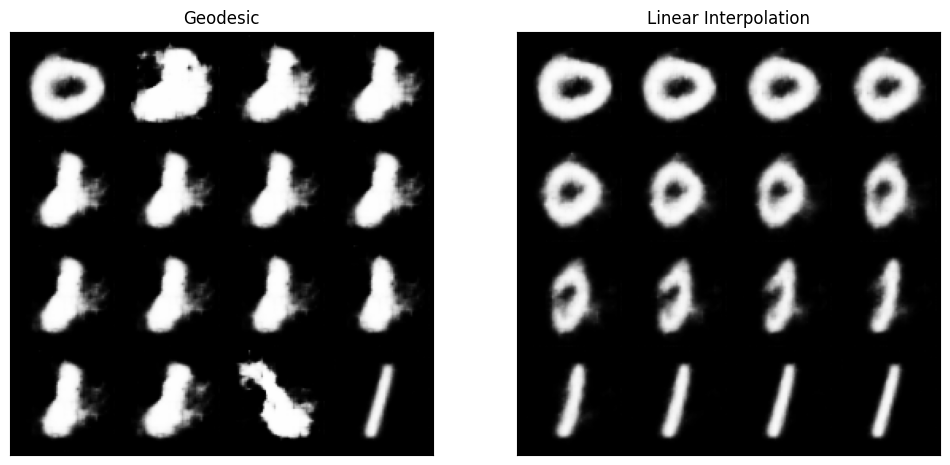

In [14]:
compute_geodesic_and_compare_to_lerp(*random_imgs)

## Getting started on nested GMMs

In [48]:
# extracting digits separately
zeros = np.array([[], [], [], [], [], [], [], []]).T
with torch.no_grad():
    for images, class_labels in dataloader:
        if torch.any(class_labels == 0):
            zeros = np.concatenate((zeros, vae.encode(images[class_labels == 0]).numpy()))

In [71]:
# extracting digits separately
twos = np.array([[], [], [], [], [], [], [], []]).T
with torch.no_grad():
    for images, class_labels in dataloader:
        if torch.any(class_labels == 2):
            twos = np.concatenate((twos, vae.encode(images[class_labels == 2]).numpy()))

In [204]:
# extracting digits separately
bgms = []
bigger_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
for i in range(10):
    digit_samples = np.array([[], [], [], [], [], [], [], []]).T
    with torch.no_grad():
        for images, class_labels in bigger_loader:
            if torch.any(class_labels == i):
                digit_samples = np.concatenate((digit_samples, vae.encode(images[class_labels == i]).numpy()))
    new_bgm = BayesianGaussianMixture(n_components=16, verbose=True, init_params='k-means++', max_iter=10000, weight_concentration_prior_type='dirichlet_distribution').fit(digit_samples)
    bgms.append(new_bgm)

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
  Iteration 120
  Iteration 130
  Iteration 140
  Iteration 150
  Iteration 160
  Iteration 170
  Iteration 180
  Iteration 190
  Iteration 200
  Iteration 210
  Iteration 220
  Iteration 230
  Iteration 240
  Iteration 250
  Iteration 260
  Iteration 270
  Iteration 280
  Iteration 290
  Iteration 300
  Iteration 310
  Iteration 320
  Iteration 330
  Iteration 340
  Iteration 350
  Iteration 360
  Iteration 370
  Iteration 380
  Iteration 390
  Iteration 400
  Iteration 410
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
  Iteration 120
  Iteration 130
  Iteration 140
  Iteration 150
  Iteration 160
  Iteration 170
  Iteration 180
  Iteration 19

In [179]:
bgm = BayesianGaussianMixture(n_components=16, verbose=True, init_params='k-means++', max_iter=10000, weight_concentration_prior_type='dirichlet_distribution').fit(twos)

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
  Iteration 120
  Iteration 130
  Iteration 140
  Iteration 150
  Iteration 160
  Iteration 170
  Iteration 180
  Iteration 190
  Iteration 200
  Iteration 210
  Iteration 220
  Iteration 230
  Iteration 240
  Iteration 250
  Iteration 260
  Iteration 270
  Iteration 280
  Iteration 290
  Iteration 300
  Iteration 310
  Iteration 320
  Iteration 330
  Iteration 340
  Iteration 350
  Iteration 360
  Iteration 370
  Iteration 380
  Iteration 390
  Iteration 400
  Iteration 410
  Iteration 420
  Iteration 430
  Iteration 440
  Iteration 450
  Iteration 460
  Iteration 470
  Iteration 480
  Iteration 490
  Iteration 500
  Iteration 510
  Iteration 520
  Iteration 530
  Iteration 540
  Iteration 550
  Iteration 560
  Iteration 570
  Iteration 580
  Iteration 590
  Iteration 600
  Iteration 610
  Iteration 620


In [180]:
bgm_twos = D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(bgm.weights_)),
    component_distribution=D.MultivariateNormal(
        loc=torch.as_tensor(bgm.means_),
        covariance_matrix=torch.as_tensor(bgm.covariances_)
    )
)

In [220]:
bgms_torch = [D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(bgmm.weights_, device='cuda', dtype=torch.float32)),
    component_distribution=D.MultivariateNormal(
        loc=torch.as_tensor(bgmm.means_, device='cuda', dtype=torch.float32),
        covariance_matrix=torch.as_tensor(bgmm.covariances_, device='cuda', dtype=torch.float32)
    )
) for bgmm in bgms]

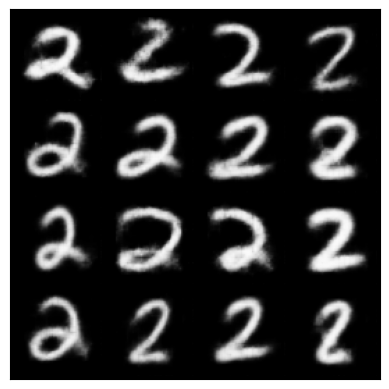

In [214]:
samples = bgm_twos.sample((16,)).to(torch.float32)
show_img(make_grid(vae.decode(samples), nrow=4))

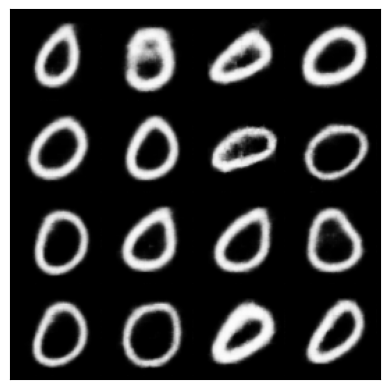

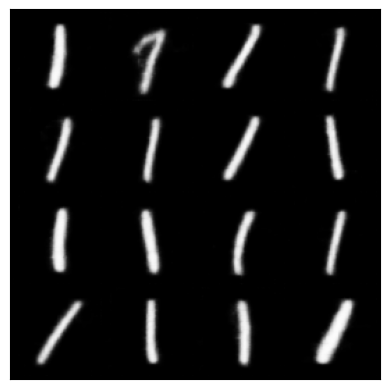

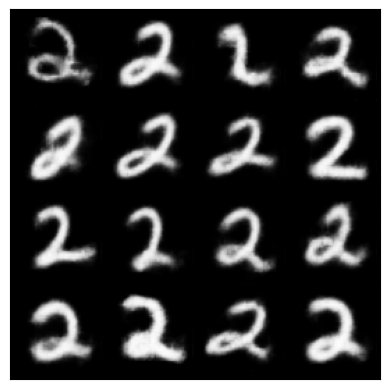

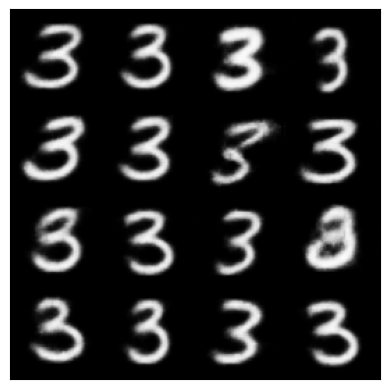

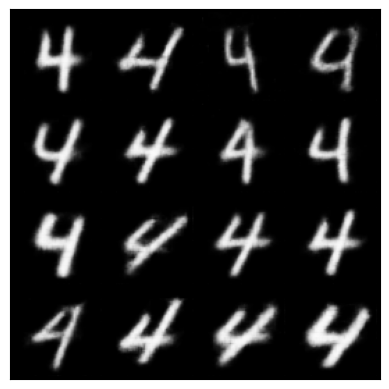

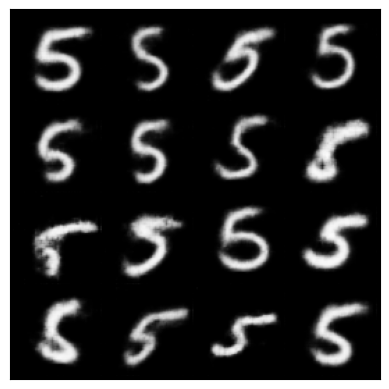

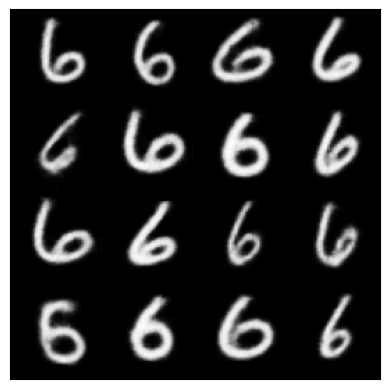

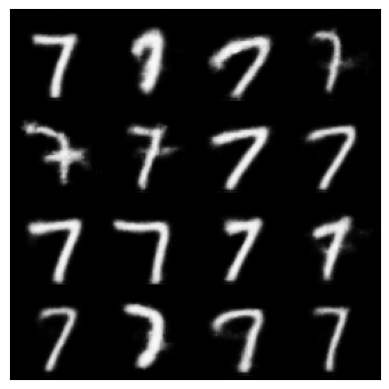

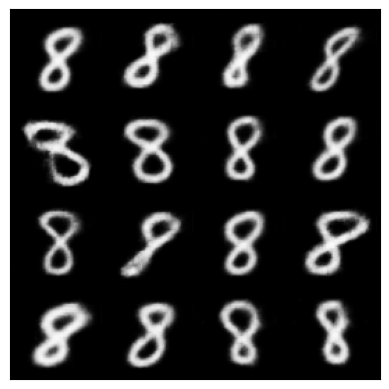

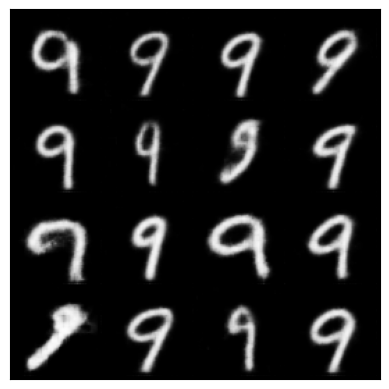

In [221]:
for i in range(10):
    show_img(make_grid(vae.decode(bgms_torch[i].sample((16,)).to(torch.float32)), nrow=4))

In [230]:
def log_posterior(x: torch.Tensor) -> torch.Tensor:
    cond_log_likelihoods = torch.stack([
        bgmm.log_prob(x) for bgmm in bgms_torch
    ], dim=-1)
    return cond_log_likelihoods - torch.logsumexp(cond_log_likelihoods, dim=-1, keepdim=True)

In [232]:
M_nestedBGM = FisherLogPosteriorManifold(log_posterior)

optimizing geodesic:   0%|          | 6/6000 [00:00<01:41, 59.06it/s, loss=0.365]

optimizing geodesic: 100%|██████████| 6000/6000 [01:22<00:00, 72.31it/s, loss=0.0873]


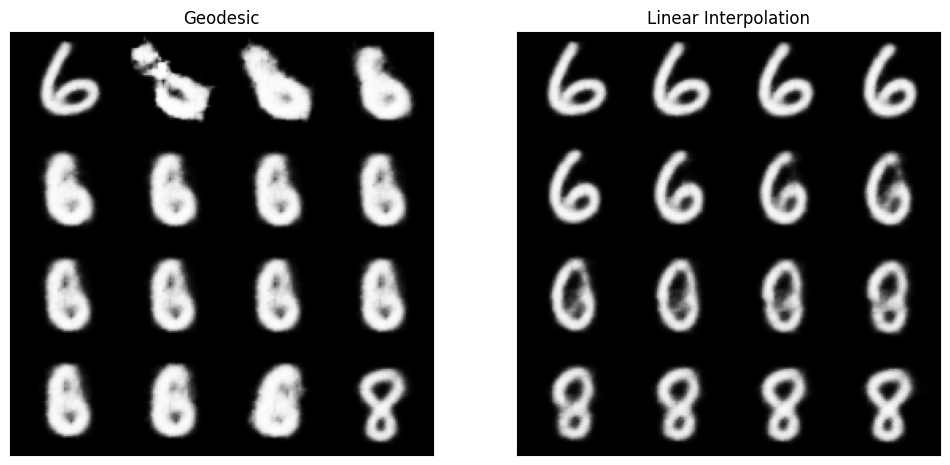

In [237]:
compute_geodesic_and_compare_to_lerp(*random_imgs, manifold=M_nestedBGM, n_iter=6000)

# Normal nested GMM fit with EM algorithm

In [9]:
# extracting digits separately
twos = np.array([[], [], [], [], [], [], [], []]).T
with torch.no_grad():
    for images, class_labels in dataloader:
        if torch.any(class_labels == 2):
            twos = np.concatenate((twos, vae.encode(images[class_labels == 2]).numpy()))

In [10]:
gmm_twos = GaussianMixture(n_components=16, init_params='k-means++', verbose=True, max_iter=10000).fit(twos)

Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.


In [ ]:
gmm_twos_torch = D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(gmm_twos.weights_, device='cuda', dtype=torch.float32)),
    component_distribution=D.MultivariateNormal(
        loc=torch.as_tensor(gmm_twos.means_, device='cuda', dtype=torch.float32),
        covariance_matrix=torch.as_tensor(gmm_twos.covariances_, device='cuda', dtype=torch.float32)
    )
)

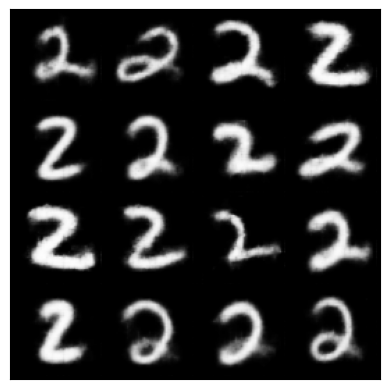

In [ ]:
show_img(make_grid(vae.decode(gmm_twos_torch.sample((16,))), nrow=4))

In [5]:
# extracting digits separately
gmms = []
bigger_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
for i in range(10):
    digit_samples = np.array([[], [], [], [], [], [], [], []]).T
    with torch.no_grad():
        for images, class_labels in bigger_loader:
            if torch.any(class_labels == i):
                digit_samples = np.concatenate((digit_samples, vae.encode(images[class_labels == i]).numpy()))
    new_gmm = GaussianMixture(n_components=16, verbose=True, init_params='k-means++', max_iter=10000).fit(digit_samples)
    gmms.append(new_gmm)

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.


In [6]:
gmms_torch = [D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(gm.weights_, device='cuda', dtype=torch.float32)),
    component_distribution=D.MultivariateNormal(
        loc=torch.as_tensor(gm.means_, device='cuda', dtype=torch.float32),
        covariance_matrix=torch.as_tensor(gm.covariances_, device='cuda', dtype=torch.float32)
    )
) for gm in gmms]

In [ ]:
digit_counts = torch.zeros(10)
for _, labels in bigger_loader:
    for i in range(10):
        digit_counts[i] += (labels == i).sum()

In [78]:
log_prior = (torch.log(digit_counts) - torch.log(digit_counts.sum())).cuda()

In [79]:
def log_posterior(x: torch.Tensor) -> torch.Tensor:
    cond_log_likelihoods = torch.stack([
        gm.log_prob(x) for gm in gmms_torch
    ], dim=-1) + log_prior
    return cond_log_likelihoods - torch.logsumexp(cond_log_likelihoods, dim=-1, keepdim=True)

In [80]:
M_nestedGMM = FisherLogPosteriorManifold(log_posterior)

In [12]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))

optimizing geodesic: 100%|██████████| 10000/10000 [02:18<00:00, 72.14it/s, loss=0.637]


In [13]:
linline = lerp(*vae.encode(random_imgs), n=16)

In [19]:
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())

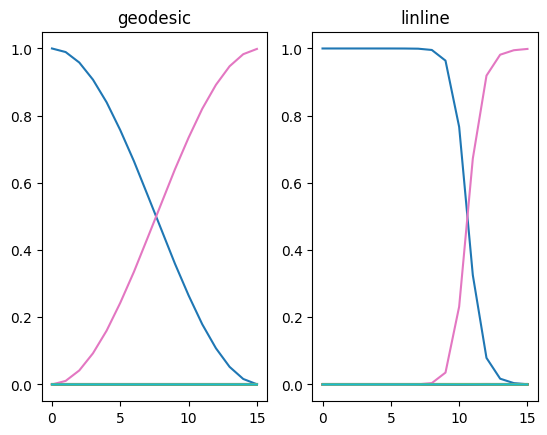

In [23]:
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()

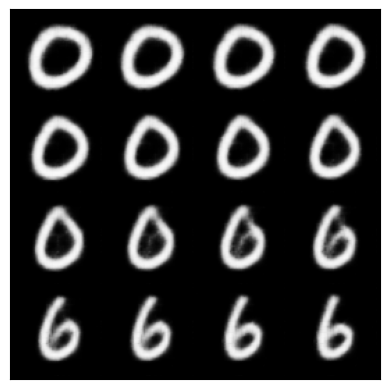

In [24]:
show_img(make_grid(vae.decode(linline), nrow=4))

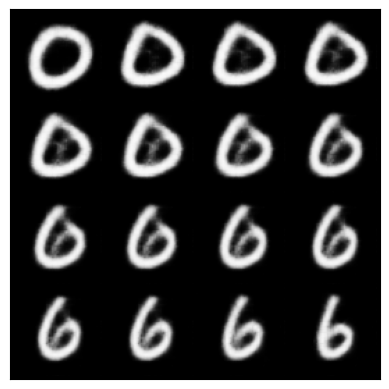

In [25]:
show_img(make_grid(vae.decode(geodesic), nrow=4))

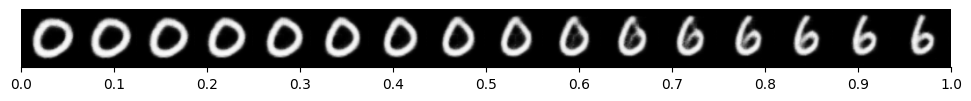

In [51]:
show_latent_curve(linline)

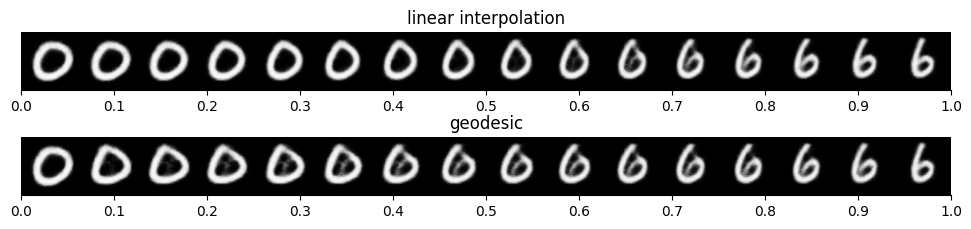

In [54]:
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

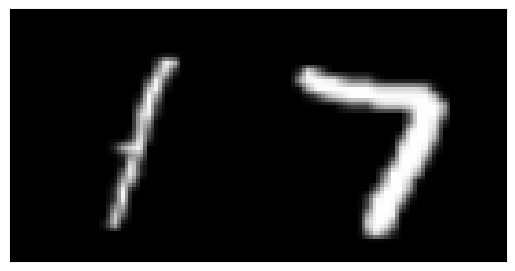

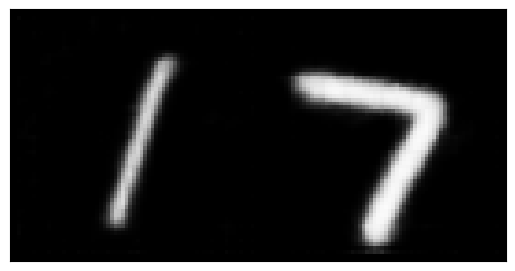

In [56]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:16<00:00, 73.43it/s, loss=0.656]


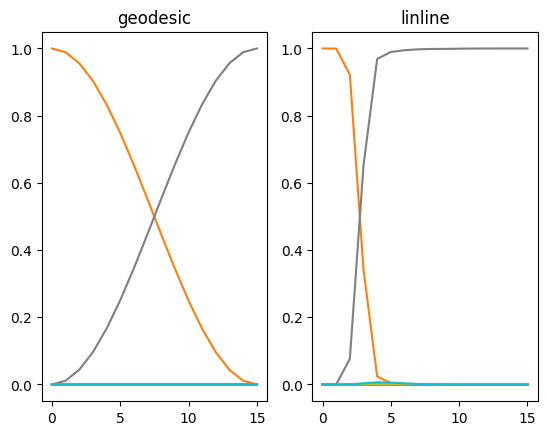

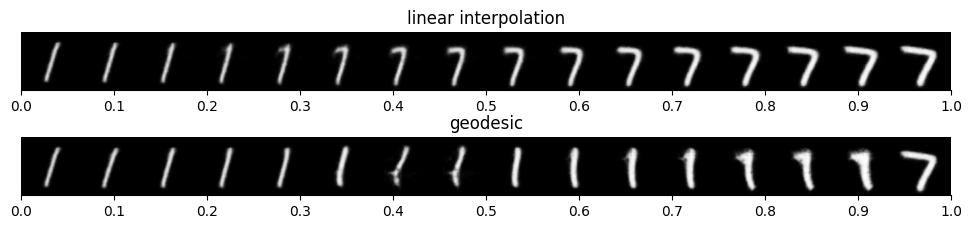

In [81]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

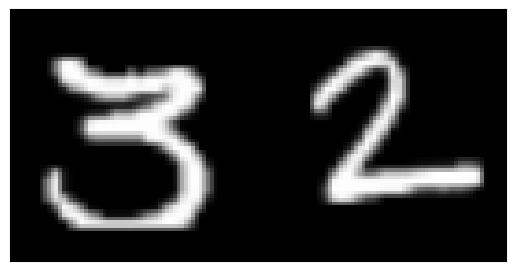

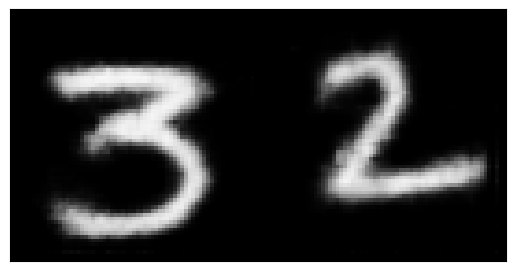

In [91]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:11<00:00, 75.88it/s, loss=0.657]


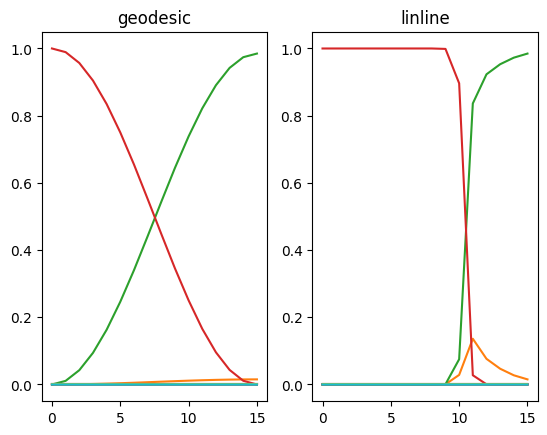

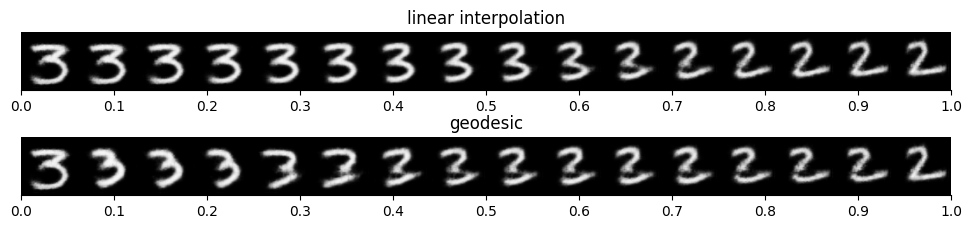

In [ ]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

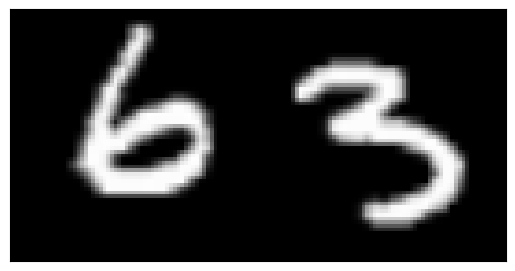

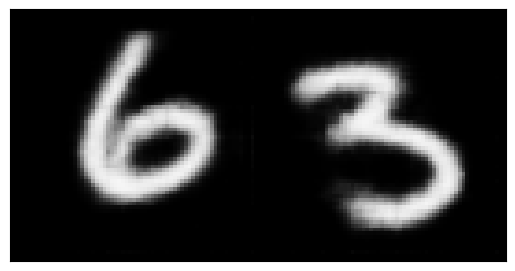

In [101]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:13<00:00, 74.96it/s, loss=0.66]


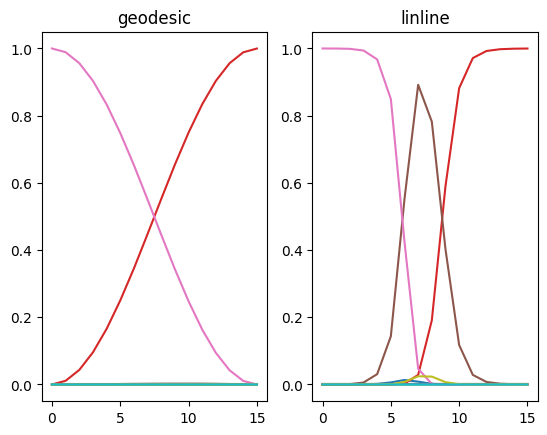

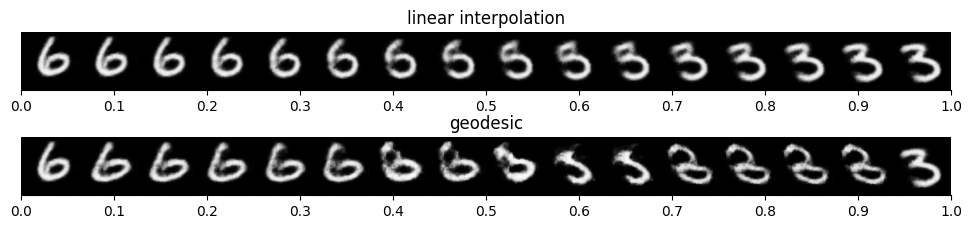

In [102]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

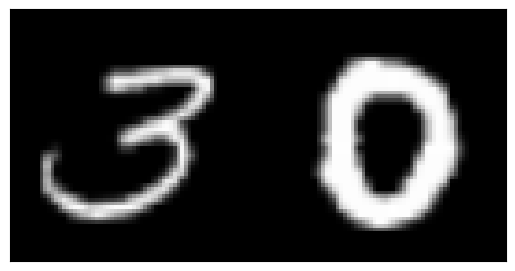

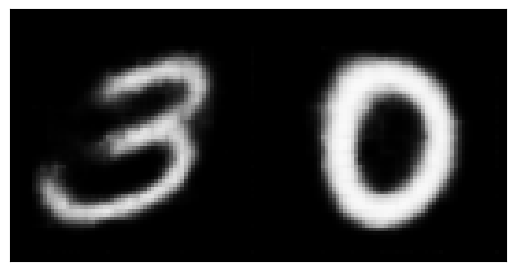

In [104]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:13<00:00, 74.98it/s, loss=0.647]


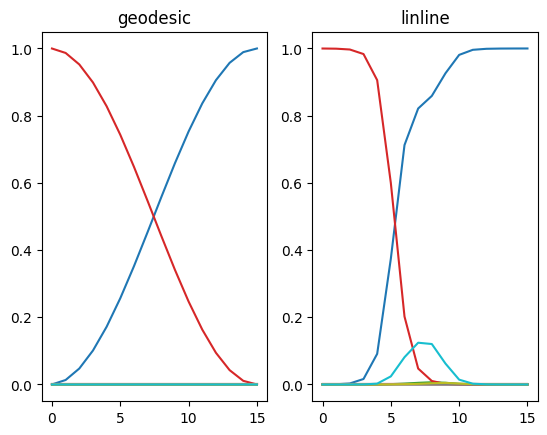

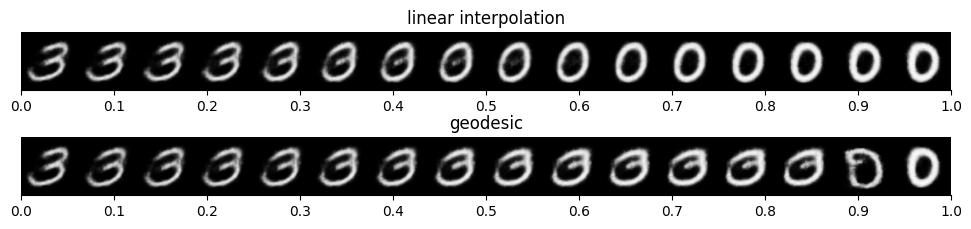

In [105]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

In [106]:
torch.save(gmms_torch, 'trained_checkpoints/latent_nested_gmm.pt')

In [107]:
test_load = torch.load('trained_checkpoints/latent_nested_gmm.pt')

/tmp/user/5678/ipykernel_414135/3724848814.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_load = torch.load('trained_checkpoints/latent_nested_gmm.pt')


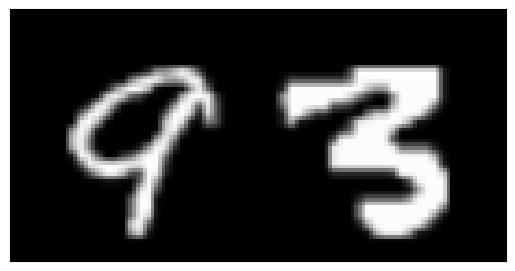

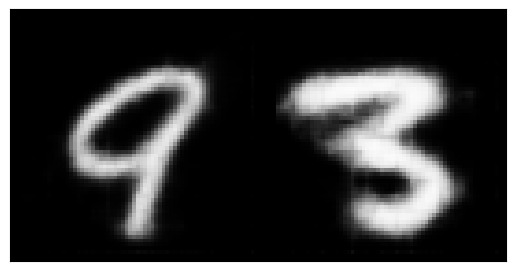

In [133]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:08<00:00, 77.87it/s, loss=0.644]


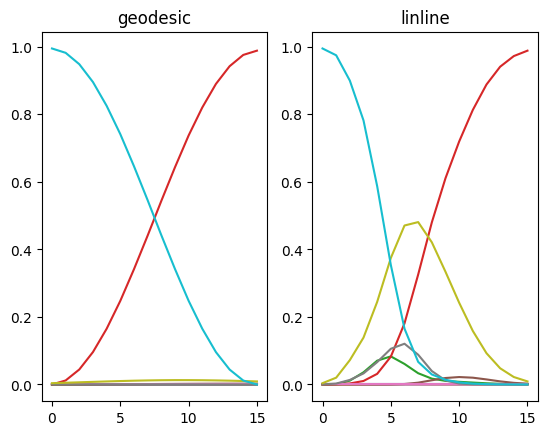

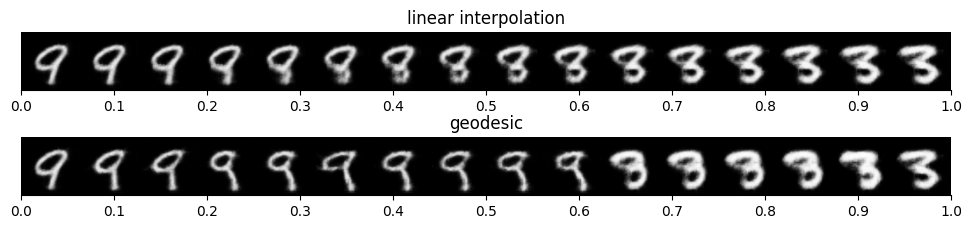

In [134]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

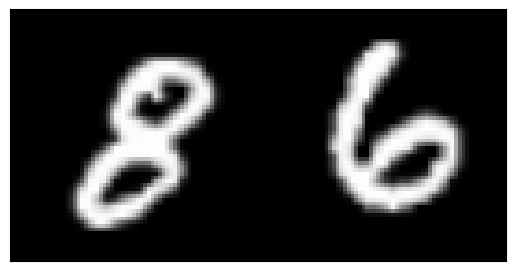

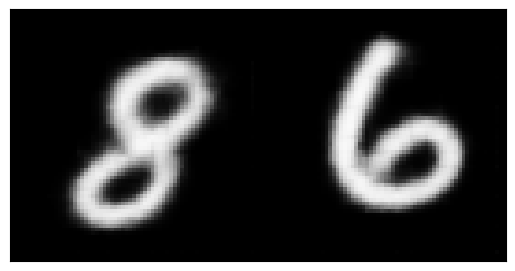

In [137]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:11<00:00, 76.28it/s, loss=0.658]


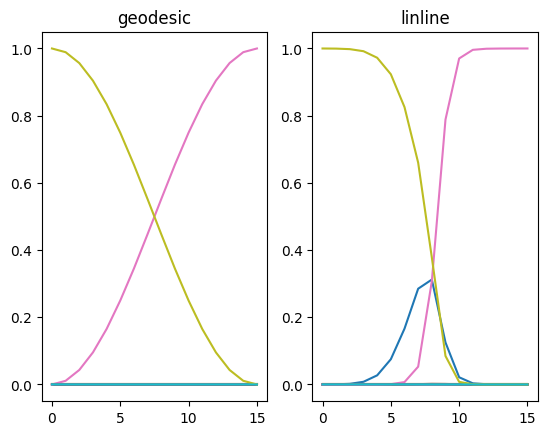

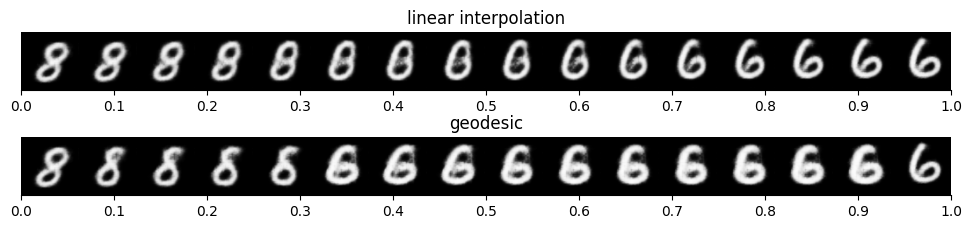

In [138]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

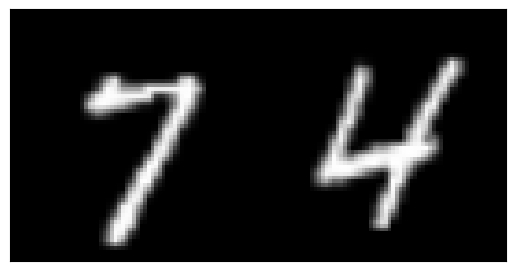

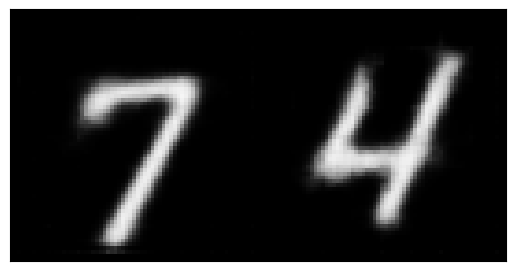

In [148]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [02:25<00:00, 68.70it/s, loss=0.659]


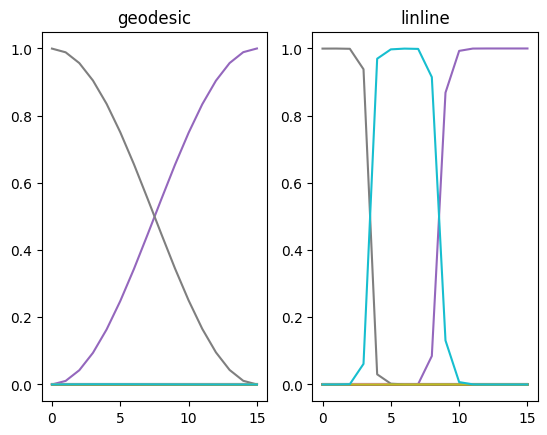

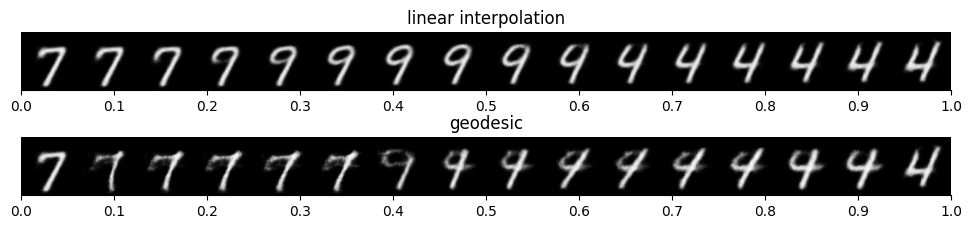

In [149]:
geodesic = M_nestedGMM.optimize_geodesic(*vae.encode(random_imgs))
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

## Karcher mean of digits w/ common geometric features

In [180]:
def compute_and_plot_gmm_Karcher_mean(*images: torch.Tensor, manifold = M_nestedGMM, n_iter=5000):
    latent_images = [vae.encode(image) for image in images]
    karcher_mean = manifold.optimize_Karcher_mean(*latent_images, n_iter=n_iter)
    latent_mean = sum(latent_images, torch.zeros(())) / len(latent_images)
    fig, (axl, axm, axr) = plt.subplots(1, 3, figsize=(12, 2.5), gridspec_kw={'width_ratios': [len(latent_images),1, 1]})
    show_img(make_grid(vae.decode(torch.stack(latent_images)).cpu()), ax=axl)
    axl.set_title('images')
    show_img(vae.decode(latent_mean).cpu(), ax=axm)
    axm.set_title('latent mean')
    show_img(vae.decode(karcher_mean).cpu(), ax=axr)
    axr.set_title('Karcher mean')

In [163]:
def get_random_image_of_class(dataset, label: int):
    loader = DataLoader(dataset, batch_size=2, shuffle=True)
    itr = iter(loader)
    while True:
        imgs, lb = next(itr)
        if torch.any(lb == label):
            return imgs[lb == label][0]

def get_random_images_of_classes(dataset, labels: list[int]):
    return torch.stack([get_random_image_of_class(dataset, lb) for lb in labels])

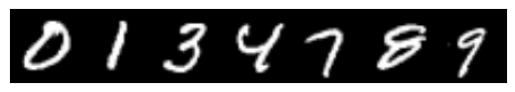

In [173]:
acc_images = get_random_images_of_classes(dataset, [0, 1, 3, 4, 7, 8, 9])
show_img(make_grid(acc_images))

optimizing Karcher mean:   0%|          | 0/5000 [00:00<?, ?it/s]

optimizing Karcher mean: 100%|██████████| 5000/5000 [05:37<00:00, 14.83it/s, loss=39.1]


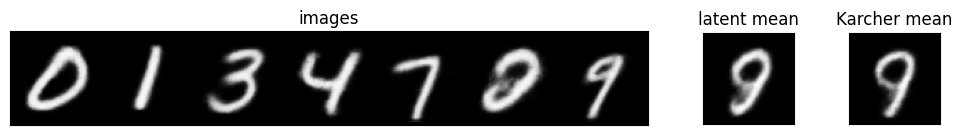

In [181]:
compute_and_plot_gmm_Karcher_mean(*acc_images)

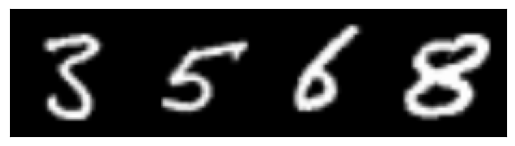

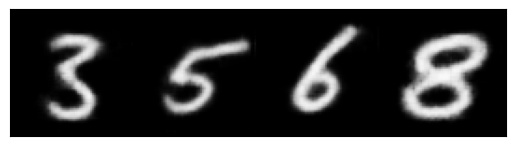

In [199]:
acc_images = get_random_images_of_classes(dataset, [3, 5, 6, 8])
show_img(make_grid(acc_images))
show_img(make_grid(vae.decode(vae.encode(acc_images))))

optimizing Karcher mean: 100%|██████████| 5000/5000 [03:17<00:00, 25.37it/s, loss=20.2]


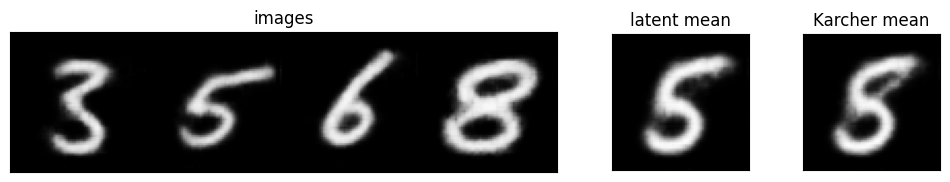

In [200]:
compute_and_plot_gmm_Karcher_mean(*acc_images)

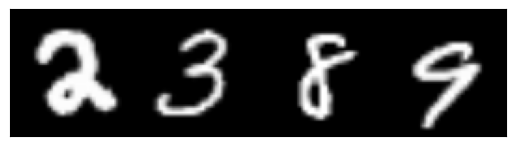

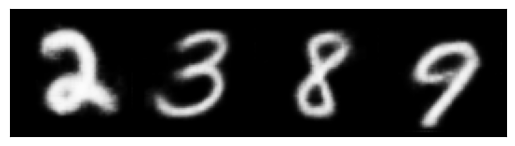

In [216]:
acc_images = get_random_images_of_classes(dataset, [2, 3, 8, 9])
show_img(make_grid(acc_images))
show_img(make_grid(vae.decode(vae.encode(acc_images))))

optimizing Karcher mean: 100%|██████████| 5000/5000 [03:14<00:00, 25.73it/s, loss=16.3]


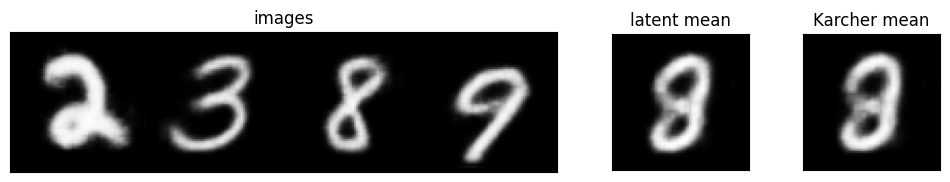

In [217]:
compute_and_plot_gmm_Karcher_mean(*acc_images)